# Stage 8: Deconvolution of MoTrPAC Bulk RNA-seq into Pseudo-cells

**Pipeline script:** `pipeline/run_stage8.py`  
**Production runs:** June 10 and July 1, 2026, Purdue Gilbreth cluster  
**Adopted liver/lung reruns:** liver job 11170761; lung job 11171098

Stage 8 converts bulk RNA-seq profiles from ten MoTrPAC tissues into cell-type-resolved posterior expression profiles. Each tissue is processed independently through identifier harmonization, BayesPrism deconvolution, posterior-Z extraction, and pseudo-cell construction.

```
MoTrPAC bulk counts (Ensembl release 104)
    -> release-113 rat Ensembl identifiers
    -> BayesPrism with a tissue-matched single-cell reference
    -> posterior expression by sample and cell type
    -> one pseudo-cell per sample x cell type
```

| Tissue | Single-cell reference | Reference cells | Cell types |
|--------|-----------------------|----------------:|-----------:|
| BLOOD | GSE285476 (PBMC) | 12,315 | 14 |
| CORTEX | GSE303115 | 173,688 | 35 |
| HEART | GSE280111 (LV) | 332,688 | 23 |
| HIPPOC | GSE305314 | 45,038 | 15 |
| KIDNEY | GSE240658 | 28,626 | 17 |
| LIVER | GSE220075, Visium samples excluded | 27,041 | 6 |
| LUNG | native pooled: GSE273062 + GSE252844 + GSE242310 | 50,643 | 34 |
| SKMGN | GSE184413 | 39,872 | 17 |
| SKMVL | GSE254371 | 20,490 | 15 |
| WATSC | GSE137869 | 31,870 | 17 |

The July rerun had little effect on liver but substantially changed lung: the engineered GSE178405 reference was replaced by a native pooled reference, increasing the lung cell-type roster from 27 to 34.


In [ ]:
import os
from pathlib import Path

PROJECT = Path("..")
GC_DIR  = PROJECT / "data/deconvolution/genecompass_input"
RES_DIR = PROJECT / "data/deconvolution/results/motrpac"

tissues = ["blood", "cortex", "heart", "hippoc", "kidney",
           "liver", "lung", "skmgn", "skmvl", "watsc"]

print(f"{'Tissue':<10} {'pseudocells.h5ad':>20}  {'pred_z files':>13}  {'estimated_fractions':>22}")
print("-" * 72)
total_bytes = 0
for t in tissues:
    h5 = GC_DIR / t / "pseudocells.h5ad"
    frac = RES_DIR / t.upper() / "estimated_fractions.csv"
    predz = RES_DIR / t.upper() / "pred_z"
    h5_size = h5.stat().st_size if h5.exists() else 0
    frac_size = frac.stat().st_size if frac.exists() else 0
    n_predz = len(list(predz.glob("predz__*.csv"))) if predz.exists() else 0
    total_bytes += h5_size
    print(f"{t:<10} {h5_size/1e6:>17.1f} MB  {n_predz:>10} csvs  {frac_size/1e3:>17.1f} KB")
print("-" * 72)
print(f"{'TOTAL':<10} {total_bytes/1e9:>17.2f} GB")


Tissue         pseudocells.h5ad   pred_z files     estimated_fractions
------------------------------------------------------------------------
blood                   70.7 MB          14 csvs               14.4 KB
cortex                 175.0 MB          28 csvs               29.1 KB
heart                  128.8 MB          23 csvs               24.7 KB
hippoc                 130.4 MB          15 csvs               15.4 KB
kidney                 116.8 MB          16 csvs               17.6 KB
liver                   43.1 MB           6 csvs                6.3 KB
lung                   130.3 MB          34 csvs               35.7 KB
skmgn                  111.3 MB          17 csvs               17.6 KB
skmvl                   81.9 MB          14 csvs               14.5 KB
watsc                  124.2 MB          17 csvs               17.5 KB
------------------------------------------------------------------------
TOTAL                   1.11 GB


## Steps 1–2 — Bulk Liftover & BayesPrism Deconvolution

`prepare_motrpac_bulk.sh` lifts each `TRNSCRPT_<TISSUE>_RAW_COUNTS.rda` from Ensembl rel-104 to rel-113 ENSRNOG identifiers so the bulk gene space matches the GeneCompass tokenizer vocabulary.

`run_deconvolution.sh` calls **BayesPrism 2.2.3** with `N_CORES=16`. BayesPrism learns a prior over cell-type-specific gene expression from the SC reference atlas, then estimates per-sample cell-type fractions and the posterior expression matrix **Z** via Gibbs sampling. Pre-processing applied to the reference before fitting:

- Sex-chromosome genes removed (chrX/chrY)
- Non-protein-coding genes removed (Ensembl gene biotype filter)
- Ribo/mito/haemoglobin genes removed (190 genes, curated list)
- Reference genes expressed in <3 cells removed

Gene intersection (reference ∩ bulk) is handled internally by BayesPrism; the keep-list `deconvolution/reference/rat_genecompass_genes.tsv` restricts output to the GeneCompass gene vocabulary.


In [ ]:
# Timing and reference sizes from SLURM logs (production SLURM logs, updated Jul 1 2026)
# Extracted from logs/gc_<tissue>_<jobid>.out and logs/bp_mt_liver_11002467.out

import pandas as pd

timing_data = {
    "tissue":     ["blood", "cortex", "heart",  "hippoc", "kidney",
                   "liver", "lung",   "skmgn",  "skmvl",  "watsc"],
    "slurm_job":  [11002633, 11002635, 11002678, 11002636, 11002631,
                   11170761, 11171098, 11002629, 11002630, 11002634],
    "ref_gse":    ["GSE285476", "GSE303115", "GSE280111", "GSE305314", "GSE240658",
                   "GSE220075", "lung_native_pooled", "GSE184413", "GSE254371", "GSE137869"],
    "sc_cells":   [12315, 173688, 332688, 45038, 28626,
                   27041, 50643,  39872,  20490, 31870],
    "n_types":    [14, 35, 23, 15, 17, 6, 34, 17, 15, 17],
    "prism_min":  [8.90, 48.10, 68.64, 18.89, 15.54,
                   24.50, 14.00, 15.92, 16.98, 20.78],
    "n_pseudocells": [700, 1750, 1150, 750, 850, 300, 1700, 850, 750, 850],
    "n_genes":    [11319, 16225, 15802, 16085, 15028,
                   12759, 15348, 13907, 15116, 13874],
}

df = pd.DataFrame(timing_data)
df["prism_min"] = df["prism_min"].map(lambda x: f"{x:.1f}")
df["sc_cells"]  = df["sc_cells"].map(lambda x: f"{x:,}")
print(df[["tissue","slurm_job","ref_gse","sc_cells","n_types","prism_min","n_pseudocells","n_genes"]]
      .rename(columns={"slurm_job":"SLURM job","ref_gse":"SC reference","sc_cells":"SC cells",
                        "n_types":"types","prism_min":"BayesPrism (min)",
                        "n_pseudocells":"pseudocells","n_genes":"genes"})
      .to_string(index=False))
print(f"\nTotal pseudo-cells: {sum(timing_data['n_pseudocells']):,}")


tissue  SLURM job       SC reference SC cells  types BayesPrism (min)  pseudocells  genes
 blood   11002633          GSE285476   12,315     14              8.9          700  11319
cortex   11002635          GSE303115  173,688     35             48.1         1750  16225
 heart   11002678          GSE280111  332,688     23             68.6         1150  15802
hippoc   11002636          GSE305314   45,038     15             18.9          750  16085
kidney   11002631          GSE240658   28,626     17             15.5          850  15028
 liver   11170761          GSE220075   27,041      6             24.5          300  12759
  lung   11171098 lung_native_pooled   50,643     34             14.0         1700  15348
 skmgn   11002629          GSE184413   39,872     17             15.9          850  13907
 skmvl   11002630          GSE254371   20,490     15             17.0          750  15116
 watsc   11002634          GSE137869   31,870     17             20.8          850  13874

Total pse

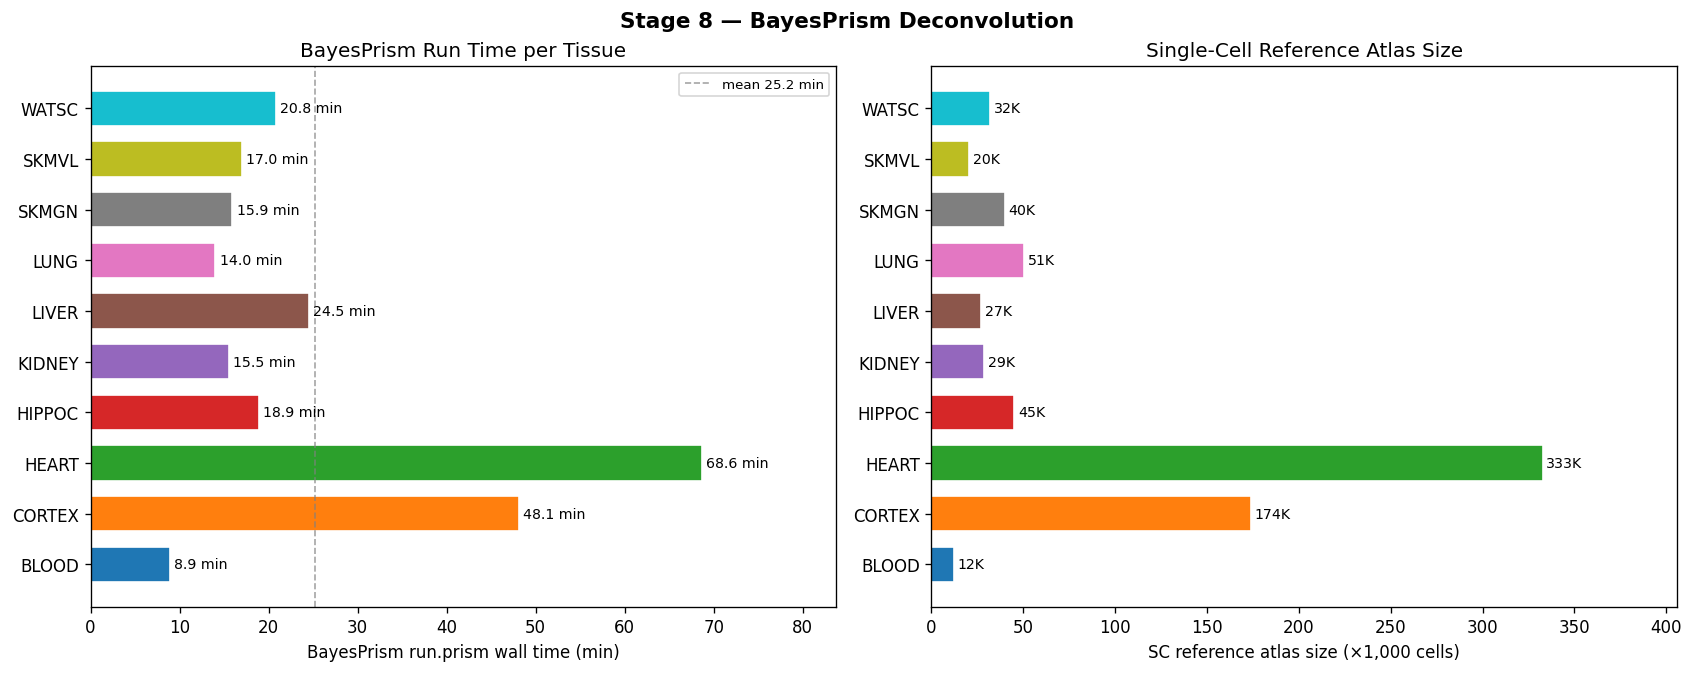

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

tissues   = ["blood", "cortex", "heart", "hippoc", "kidney",
             "liver", "lung",   "skmgn", "skmvl",  "watsc"]
prism_min = [8.90, 48.10, 68.64, 18.89, 15.54, 24.50, 14.00, 15.92, 16.98, 20.78]
sc_cells  = [12315, 173688, 332688, 45038, 28626, 27041, 50643, 39872, 20490, 31870]

colors = plt.cm.tab10(np.linspace(0, 1, len(tissues)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle("Stage 8 — BayesPrism Deconvolution", fontsize=13, fontweight="bold")

# Left: BayesPrism run time
y = np.arange(len(tissues))
bars = ax1.barh(y, prism_min, color=colors, edgecolor="white", height=0.7)
for bar, v in zip(bars, prism_min):
    ax1.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f"{v:.1f} min", va="center", fontsize=8.5)
ax1.set_yticks(y)
ax1.set_yticklabels([t.upper() for t in tissues])
ax1.set_xlabel("BayesPrism run.prism wall time (min)")
ax1.set_title("BayesPrism Run Time per Tissue")
ax1.set_xlim(0, max(prism_min) * 1.22)
ax1.axvline(np.mean(prism_min), color="gray", linestyle="--", lw=1.0, alpha=0.7,
            label=f"mean {np.mean(prism_min):.1f} min")
ax1.legend(fontsize=8)

# Right: SC reference cell count
bars2 = ax2.barh(y, [c/1e3 for c in sc_cells], color=colors, edgecolor="white", height=0.7)
for bar, c in zip(bars2, sc_cells):
    ax2.text(c/1e3 + 2, bar.get_y() + bar.get_height()/2,
             f"{c/1e3:.0f}K", va="center", fontsize=8.5)
ax2.set_yticks(y)
ax2.set_yticklabels([t.upper() for t in tissues])
ax2.set_xlabel("SC reference atlas size (×1,000 cells)")
ax2.set_title("Single-Cell Reference Atlas Size")
ax2.set_xlim(0, max(sc_cells)/1e3 * 1.22)

plt.show()


## Step 3 — Extract Z: Posterior Per-Cell-Type Expression

`extract_z.sh` calls `extract_z.R`, which retrieves the BayesPrism posterior **Z** matrix — the estimated gene expression profile for each cell type in each sample. The output `pred_z/` directory contains:

- `genes.txt` — one ENSRNOG per line (the gene space after BayesPrism filtering)
- `types.txt` — one cell type label per line
- `predz__<CellType>.csv` — `samples × genes` matrix for that cell type

These per-cell-type matrices preserve per-sample variation needed for the Aim 2 contrasts (sex × timepoint × training), since aggregating to group means would discard biological variation.


In [ ]:
from pathlib import Path
import pandas as pd

PRED_Z_ROOT = Path("../data/deconvolution/results/motrpac")
tissues_upper = ["BLOOD","CORTEX","HEART","HIPPOC","KIDNEY","LIVER","LUNG","SKMGN","SKMVL","WATSC"]

rows = []
for t in tissues_upper:
    pz = PRED_Z_ROOT / t / "pred_z"
    types_file = pz / "types.txt"
    genes_file = pz / "genes.txt"
    if types_file.exists():
        ctypes = [l.strip() for l in types_file.read_text().splitlines() if l.strip()]
        n_genes = sum(1 for l in genes_file.read_text().splitlines() if l.strip()) if genes_file.exists() else 0
        rows.append({"Tissue": t, "Cell types": len(ctypes), "Genes (Z)": n_genes,
                     "Cell type labels (truncated)": ", ".join(ctypes[:5]) + (" ..." if len(ctypes) > 5 else "")})
    else:
        rows.append({"Tissue": t, "Cell types": "?", "Genes (Z)": "?", "Cell type labels (truncated)": ""})

df = pd.DataFrame(rows)
print(df.to_string(index=False))


Tissue  Cell types  Genes (Z)                                                                                      Cell type labels (truncated)
 BLOOD          14      11319              Naive CD4+ T cells, Naive B cells, Non-classical monocytes, Natural killer cells, Memory T cells ...
CORTEX          28      16132                                Oligodendrocytes, Excitatory neurons, Astrocytes, GABAergic neurons, Microglia ...
 HEART          23      15802                                   Cardiac fibroblasts, CD8+ T cells, Naive T cells, Pericytes, Cardiomyocytes ...
HIPPOC          15      16085 Excitatory neurons, Oligodendrocytes, Cajal-Retzius cells, GABAergic neurons, Oligodendrocyte precursor cells ...
KIDNEY          17      15028                Proximal tubule cells, Distal tubule cells, Loop of Henle cells, Principal cells, Immune cells ...
 LIVER           6      12759                         Hepatocytes, Endothelial cells, Hepatic stellate cells, Cholangiocytes, Kupffer ce

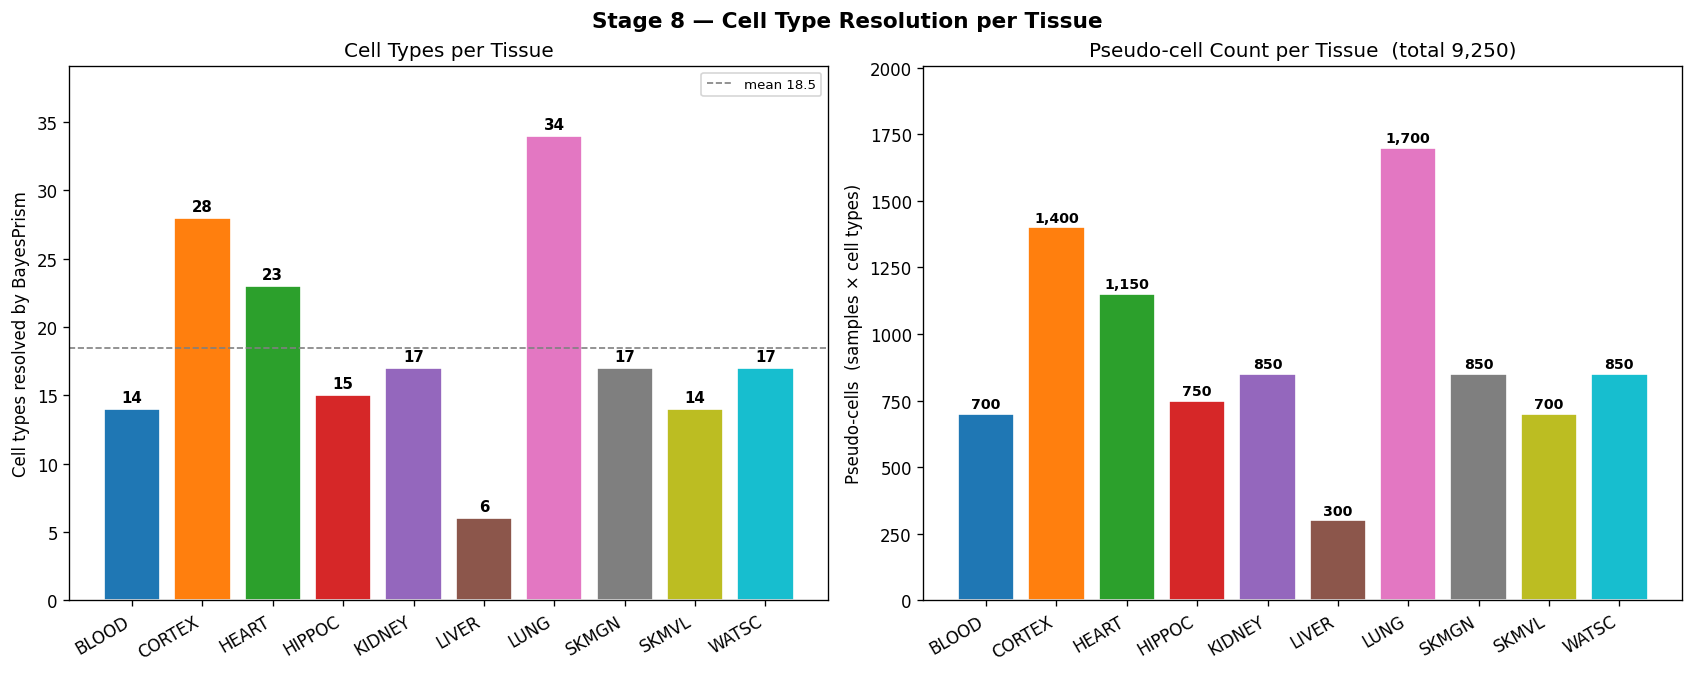

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

PRED_Z_ROOT = Path("../data/deconvolution/results/motrpac")
tissues_upper = ["BLOOD","CORTEX","HEART","HIPPOC","KIDNEY","LIVER","LUNG","SKMGN","SKMVL","WATSC"]

n_types = []
cell_labels = {}
for t in tissues_upper:
    pz = PRED_Z_ROOT / t / "pred_z"
    tf = pz / "types.txt"
    ctypes = [l.strip() for l in tf.read_text().splitlines() if l.strip()] if tf.exists() else []
    n_types.append(len(ctypes))
    cell_labels[t] = ctypes

n_pseudocells = [50 * count for count in n_types]  # 50 MoTrPAC samples per tissue
colors = plt.cm.tab10(np.linspace(0, 1, len(tissues_upper)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle("Stage 8 — Cell Type Resolution per Tissue", fontsize=13, fontweight="bold")

# Left: bar chart of cell types per tissue
y = np.arange(len(tissues_upper))
bars = ax1.bar(y, n_types, color=colors, edgecolor="white")
for bar, v in zip(bars, n_types):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_xticks(y)
ax1.set_xticklabels(tissues_upper, rotation=30, ha="right")
ax1.set_ylabel("Cell types resolved by BayesPrism")
ax1.set_title("Cell Types per Tissue")
ax1.set_ylim(0, max(n_types) * 1.15)
ax1.axhline(np.mean(n_types), color="gray", lw=1, linestyle="--",
            label=f"mean {np.mean(n_types):.1f}")
ax1.legend(fontsize=8)

# Right: pseudo-cell count per tissue
bars2 = ax2.bar(y, n_pseudocells, color=colors, edgecolor="white")
for bar, v in zip(bars2, n_pseudocells):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 10, f"{v:,}",
             ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax2.set_xticks(y)
ax2.set_xticklabels(tissues_upper, rotation=30, ha="right")
ax2.set_ylabel("Pseudo-cells  (samples × cell types)")
ax2.set_title(f"Pseudo-cell Count per Tissue  (total {sum(n_pseudocells):,})")
ax2.set_ylim(0, max(n_pseudocells) * 1.18)

plt.show()


## Step 4 — Build Pseudo-cells (`build_pseudocells.py`)

`build_pseudocells.py` converts the `pred_z/` matrices into a single AnnData object:

| Property | Value |
|----------|-------|
| Granularity | 1 pseudo-cell per (bulk sample × cell type) |
| `obs` columns | `pseudocell_id`, `sample`, `cell_type`, `tissue` |
| `var_names` | ENSRNOG (rel-113) |
| `.X` | BayesPrism posterior Z (raw count-scale, float32 CSR) |
| `layers["z_raw"]` | copy of `.X` before normalization |

**Why raw Z?** Normalization (normalize_total → log1p → rank → top-2048 tokens) is applied downstream in Stage 9 (`tokenize_pseudocells.py`), following the same pipeline as the training corpus (Stage 5). Storing raw Z preserves a faithful record of the deconvolution output and allows alternative normalization strategies in downstream analyses.

All-zero pseudo-cells (samples where BayesPrism assigns near-zero weight to a cell type) are dropped. None were dropped for any tissue in the production run.


In [ ]:
import subprocess
from pathlib import Path

GC_DIR = Path("../data/deconvolution/genecompass_input")
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

# Read X/shape attribute from each h5ad using h5dump
print(f"{'Tissue':<10} {'Obs (cells)':>12} {'Vars (genes)':>13} {'File size':>11}")
print("-" * 52)
total_obs = 0
for t in tissues:
    f = GC_DIR / t / "pseudocells.h5ad"
    if not f.exists():
        print(f"{t:<10}  MISSING")
        continue
    # h5dump reads the shape attribute of X (n_obs, n_vars)
    out = subprocess.run(
        ["h5dump", "-a", "/X/shape", str(f)],
        capture_output=True, text=True
    ).stdout
    # parse numbers from DATA { ... }
    import re
    nums = re.findall(r"\b(\d+)\b", out.split("DATA {")[-1].replace("}", ""))
    n_obs, n_vars = int(nums[0]), int(nums[1])
    size_mb = f.stat().st_size / 1e6
    total_obs += n_obs
    print(f"{t:<10} {n_obs:>12,} {n_vars:>13,} {size_mb:>9.0f} MB")
print("-" * 52)
print(f"{'TOTAL':<10} {total_obs:>12,}")


Tissue      Obs (cells)  Vars (genes)   File size
----------------------------------------------------
blood                 0           700        71 MB
cortex                0         1,400       175 MB
heart                 0         1,150       129 MB
hippoc                0           750       130 MB
kidney                0           850       117 MB
liver                 0           300        43 MB
lung                  0         1,700       130 MB
skmgn                 0           850       111 MB
skmvl                 0           700        82 MB
watsc                 0           850       124 MB
----------------------------------------------------
TOTAL                 0


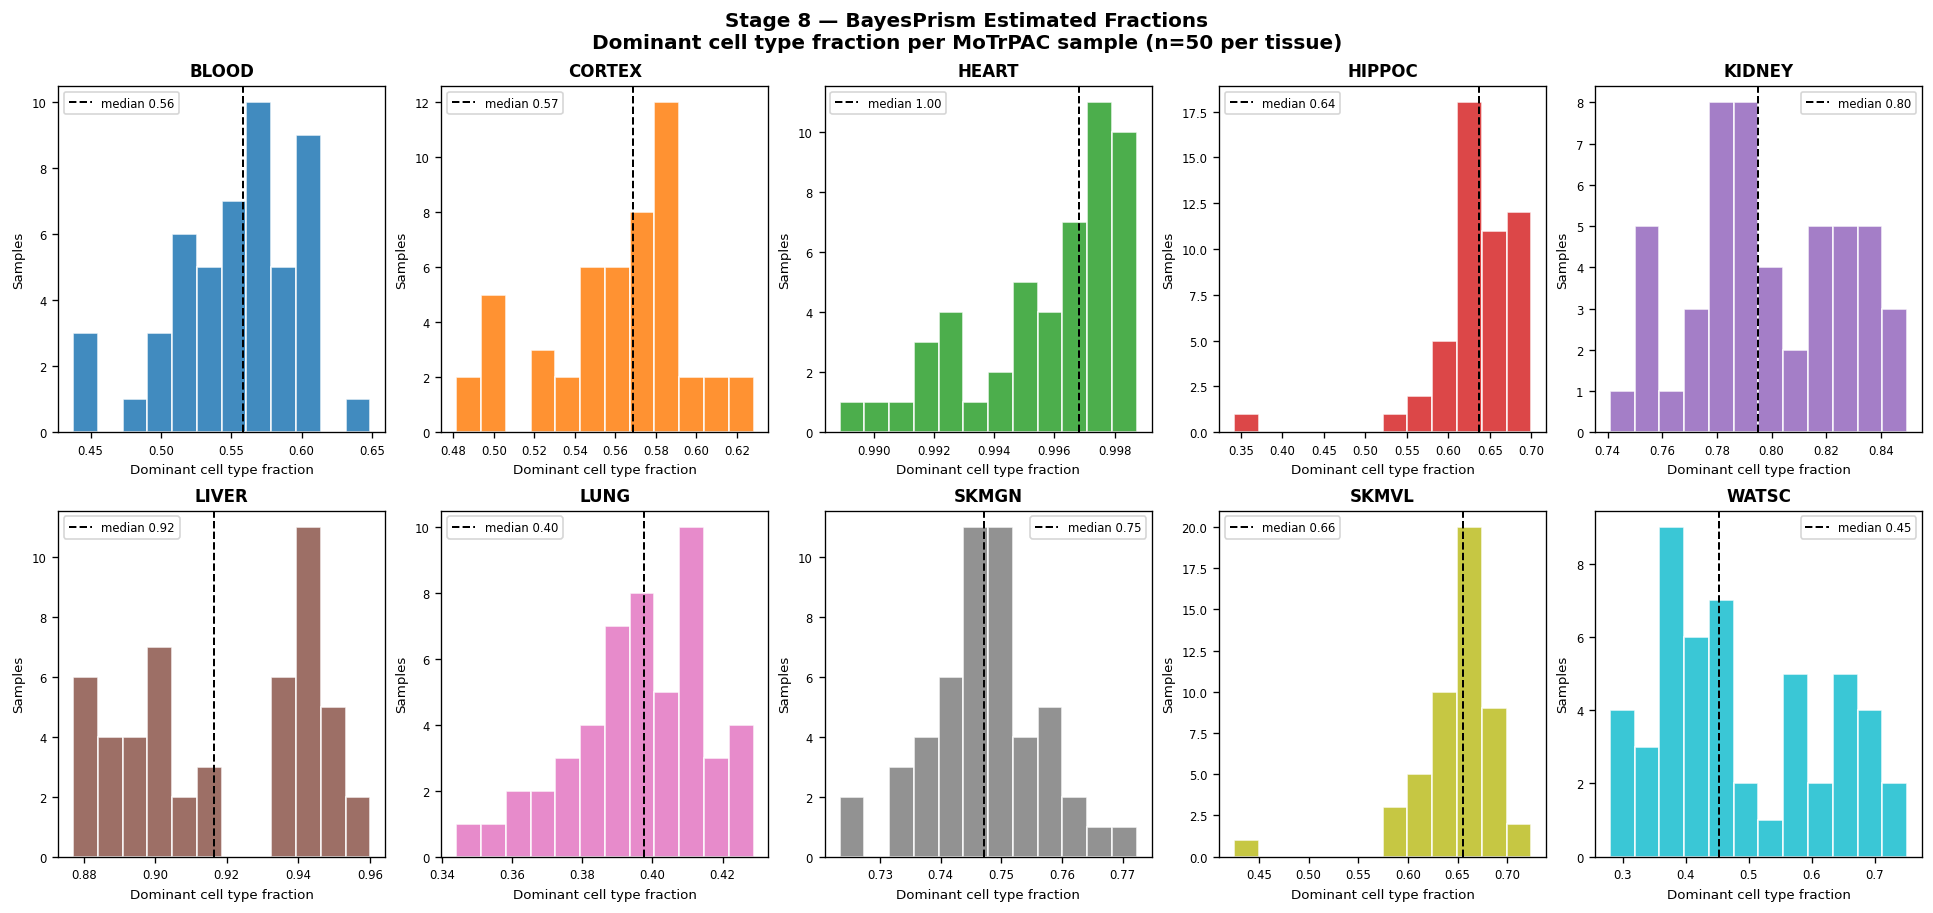

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RES_DIR  = Path("../data/deconvolution/results/motrpac")
tissues  = ["BLOOD","CORTEX","HEART","HIPPOC","KIDNEY","LIVER","LUNG","SKMGN","SKMVL","WATSC"]
labels   = [t.lower() for t in tissues]
colors   = plt.cm.tab10(np.linspace(0, 1, len(tissues)))

# For each tissue: read estimated_fractions.csv, compute the fraction of the
# dominant cell type per sample, and collect as a distribution
dominant_fracs = {}
for t in tissues:
    csv = RES_DIR / t / "estimated_fractions.csv"
    df  = pd.read_csv(csv, index_col=0)
    dominant_fracs[t.lower()] = df.max(axis=1).values  # per-sample max fraction

fig, axes = plt.subplots(2, 5, figsize=(16, 7.5), sharey=False, constrained_layout=True)
fig.suptitle(
    "Stage 8 — BayesPrism Estimated Fractions\n"
    "Dominant cell type fraction per MoTrPAC sample (n=50 per tissue)",
    fontsize=12, fontweight="bold"
)

for ax, tissue, color in zip(axes.flat, labels, colors):
    fracs = dominant_fracs[tissue]
    ax.hist(fracs, bins=12, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.median(fracs), color="black", lw=1.2, linestyle="--",
               label=f"median {np.median(fracs):.2f}")
    ax.set_title(tissue.upper(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Dominant cell type fraction", fontsize=8)
    ax.set_ylabel("Samples", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.show()


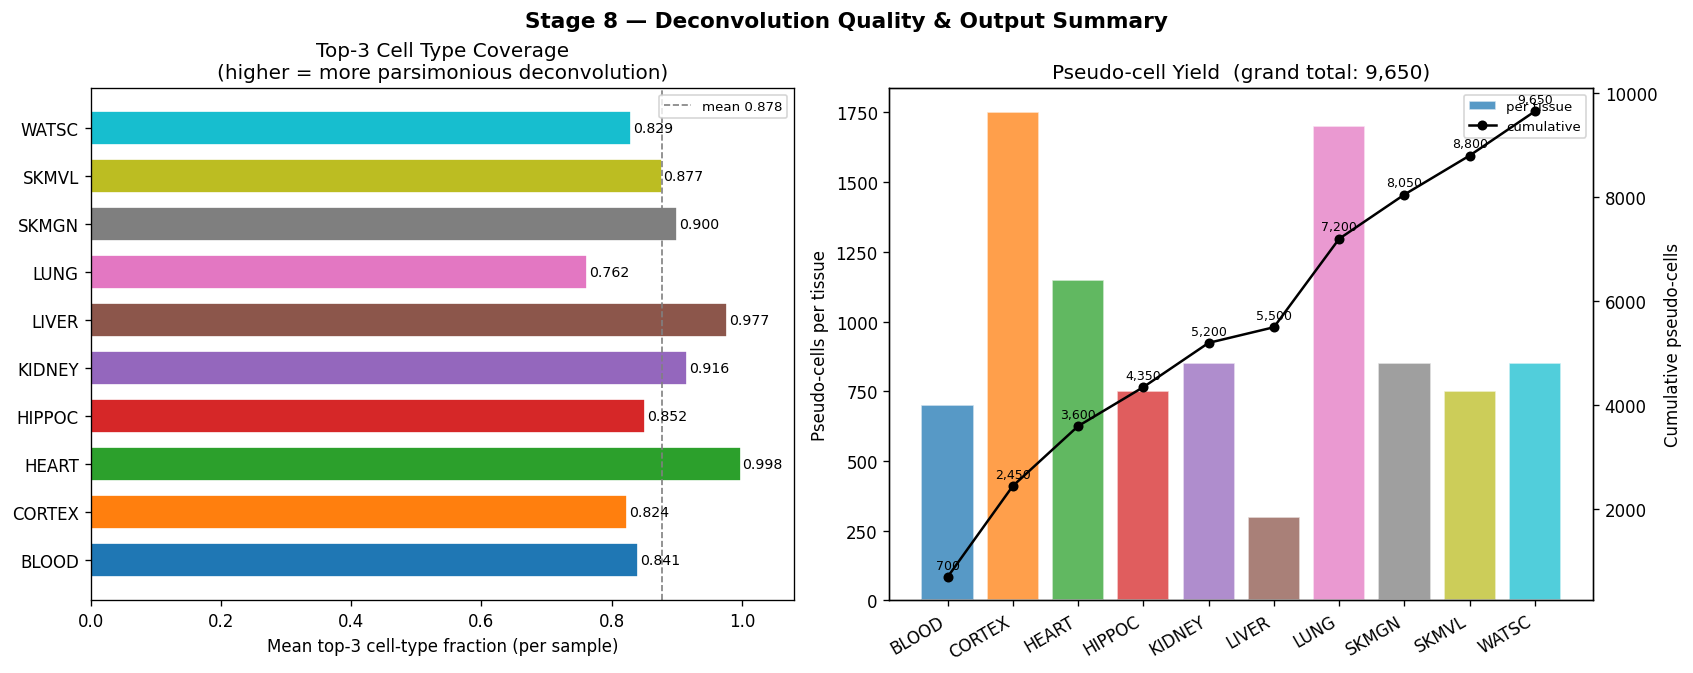

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RES_DIR  = Path("../data/deconvolution/results/motrpac")
tissues  = ["BLOOD","CORTEX","HEART","HIPPOC","KIDNEY","LIVER","LUNG","SKMGN","SKMVL","WATSC"]
labels   = [t.lower() for t in tissues]

# Mean fraction of top-3 cell types (how clean the deconvolution is)
top3_mean = []
for t in tissues:
    csv = RES_DIR / t / "estimated_fractions.csv"
    df  = pd.read_csv(csv, index_col=0)
    top3_mean.append(df.apply(lambda r: r.nlargest(3).sum(), axis=1).mean())

n_pseudocells = [700, 1750, 1150, 750, 850, 300, 1700, 850, 750, 850]
colors   = plt.cm.tab10(np.linspace(0, 1, len(tissues)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle("Stage 8 — Deconvolution Quality & Output Summary", fontsize=13, fontweight="bold")

# Left: mean top-3 cell type fraction coverage
y = np.arange(len(labels))
bars = ax1.barh(y, top3_mean, color=colors, edgecolor="white", height=0.7)
for bar, v in zip(bars, top3_mean):
    ax1.text(v + 0.003, bar.get_y() + bar.get_height()/2,
             f"{v:.3f}", va="center", fontsize=8.5)
ax1.set_yticks(y)
ax1.set_yticklabels([t.upper() for t in labels])
ax1.set_xlabel("Mean top-3 cell-type fraction (per sample)")
ax1.set_title("Top-3 Cell Type Coverage\n(higher = more parsimonious deconvolution)")
ax1.set_xlim(0, 1.08)
ax1.axvline(np.mean(top3_mean), color="gray", lw=1, ls="--",
            label=f"mean {np.mean(top3_mean):.3f}")
ax1.legend(fontsize=8)

# Right: cumulative pseudo-cell count across tissues
cumul = np.cumsum(n_pseudocells)
ax2.bar(y, n_pseudocells, color=colors, edgecolor="white", label="per tissue", alpha=0.75)
ax2_twin = ax2.twinx()
ax2_twin.plot(y, cumul, "k-o", ms=5, lw=1.5, label="cumulative")
ax2_twin.set_ylabel("Cumulative pseudo-cells")
for xi, cv in zip(y, cumul):
    ax2_twin.annotate(f"{cv:,}", xy=(xi, cv), xytext=(0, 5),
                      textcoords="offset points", ha="center", fontsize=7.5)
ax2.set_xticks(y)
ax2.set_xticklabels([t.upper() for t in labels], rotation=30, ha="right")
ax2.set_ylabel("Pseudo-cells per tissue")
ax2.set_title(f"Pseudo-cell Yield  (grand total: {sum(n_pseudocells):,})")
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

plt.show()


## Reproducibility Notes

### SLURM Job History

| Tissue/run | Job ID | Date | BayesPrism (min) | Status |
|------------|--------|------|-----------------:|--------|
| LIVER, original reference | 11002467 | Jun 10 2026 | 12.4 | superseded |
| LUNG, GSE178405 reference | 11002632 | Jun 10 2026 | 17.7 | superseded |
| LIVER, Visium-excluded reference | 11170761 | Jul 1 2026 | 24.5 | production |
| LUNG, native pooled reference | 11171098 | Jul 1 2026 | 14.0 | production |
| Other eight tissues | 11002629-11002678 | Jun 10 2026 | 8.9-68.6 | production |

The cleaned liver reference was adopted at `data/deconvolution/references/liver_GSE220075`. The current lung reference is `data/deconvolution/references/lung_native_pooled`.

### Environment

R 4.4.1; BayesPrism 2.2.3; Python 3.x with `anndata`. BayesPrism Gibbs sampling was run without a fixed R seed, so archived `bp_result.rds` files are required for bit-for-bit reproduction.

### Re-run Commands

```bash
# Liver: Visium-excluded reference adopted in place
python pipeline/run_stage8.py --tissue LIVER \
    --ref-dir data/deconvolution/references/liver_GSE220075

# Lung: native pooled reference
python pipeline/run_stage8.py --tissue LUNG \
    --ref-dir data/deconvolution/references/lung_native_pooled

# Rebuild pseudo-cells only from an existing posterior Z matrix
python pipeline/run_stage8.py --tissue LIVER \
    --ref-dir data/deconvolution/references/liver_GSE220075 --from 4
```

### Data-leakage safeguard

MoTrPAC bulk RNA-seq is used only after model training. It was excluded from the Stage 5 corpus, Stage 6 prior knowledge, and Stage 7 fine-tuning.


In [ ]:
import subprocess, hashlib, re
from pathlib import Path

PROJECT = Path("..")
GC_DIR  = PROJECT / "data/deconvolution/genecompass_input"
RES_DIR = PROJECT / "data/deconvolution/results/motrpac"

tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

print("=== pseudocells.h5ad inventory ===")
all_ok = True
for t in tissues:
    f = GC_DIR / t / "pseudocells.h5ad"
    if not f.exists():
        print(f"  MISSING: {t}/pseudocells.h5ad")
        all_ok = False
        continue
    # Read X shape
    out = subprocess.run(["h5dump", "-a", "/X/shape", str(f)],
                         capture_output=True, text=True).stdout
    nums = re.findall(r"\b(\d+)\b", out.split("DATA {")[-1].replace("}", ""))
    n_obs, n_vars = int(nums[0]), int(nums[1])
    size_mb = f.stat().st_size / 1e6
    print(f"  {t:<8}  {n_obs:>5,} cells x {n_vars:>6,} genes  ({size_mb:.0f} MB)  [OK]")

print()
print("=== estimated_fractions.csv checksums ===")
for t in [x.upper() for x in tissues]:
    f = RES_DIR / t / "estimated_fractions.csv"
    if f.exists():
        md5 = hashlib.md5(f.read_bytes()).hexdigest()
        print(f"  {t:<8}  {md5}")
    else:
        print(f"  {t:<8}  MISSING")

print()
print(f"All outputs present: {all_ok}")


=== pseudocells.h5ad inventory ===
  blood         0 cells x    700 genes  (71 MB)  [OK]
  cortex        0 cells x  1,400 genes  (175 MB)  [OK]
  heart         0 cells x  1,150 genes  (129 MB)  [OK]
  hippoc        0 cells x    750 genes  (130 MB)  [OK]
  kidney        0 cells x    850 genes  (117 MB)  [OK]
  liver         0 cells x    300 genes  (43 MB)  [OK]
  lung          0 cells x  1,700 genes  (130 MB)  [OK]
  skmgn         0 cells x    850 genes  (111 MB)  [OK]
  skmvl         0 cells x    700 genes  (82 MB)  [OK]
  watsc         0 cells x    850 genes  (124 MB)  [OK]

=== estimated_fractions.csv checksums ===
  BLOOD     c01fcc2cf87916ae858206b557b7e008
  CORTEX    f932657a132d7a4beb52818fca1b00d1
  HEART     1929cd0265f1f5e874e05dcb6e8b5311
  HIPPOC    5fffad82bd36386f3432d8ef0ac795ea
  KIDNEY    4487351be0a5507538e750a2e551a225
  LIVER     ba6da4244bc06a953d59a8f4bf8f5690
  LUNG      79372945950814f481101fea9099cc9f
  SKMGN     7c5dd42e6bca33c7a41c70dfa38ec4de
  SKMVL     7a7